# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE CASAS EUROPEAS
## DATASET: https://www.kaggle.com/datasets/thedrzee/melbourne-house-prices-dataset

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv('/content/housing_clean.csv')
df

,Rooms,Price,Regionname,Distance
0,3,1490000.0,Northern Metropolitan,3.0
1,3,1220000.0,Northern Metropolitan,3.0
2,3,1420000.0,Northern Metropolitan,3.0
3,3,1515000.0,Western Metropolitan,7.5
4,2,670000.0,Western Metropolitan,10.4
...,...,...,...,...
46760,3,595000.0,South-Eastern Metropolitan,28.8
46761,3,808000.0,Northern Metropolitan,8.4
46762,3,566000.0,Northern Metropolitan,20.6
46763,3,500000.0,Northern Metropolitan,20.6


In [ ]:
df['Regionname'].unique()

array(['Northern Metropolitan', 'Western Metropolitan',
       'Southern Metropolitan', 'South-Eastern Metropolitan',
       'Eastern Metropolitan', 'Northern Victoria', 'Eastern Victoria',
       'Western Victoria'], dtype=object)

## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [ ]:
df['Price'] = df['Price'] / 1000000
df

,Rooms,Price,Regionname,Distance
0,3,1.490,Northern Metropolitan,3.0
1,3,1.220,Northern Metropolitan,3.0
2,3,1.420,Northern Metropolitan,3.0
3,3,1.515,Western Metropolitan,7.5
4,2,0.670,Western Metropolitan,10.4
...,...,...,...,...
46760,3,0.595,South-Eastern Metropolitan,28.8
46761,3,0.808,Northern Metropolitan,8.4
46762,3,0.566,Northern Metropolitan,20.6
46763,3,0.500,Northern Metropolitan,20.6


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [ ]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['Regionname'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Regionname
Northern Metropolitan         13590
Southern Metropolitan         12539
Western Metropolitan           9432
Eastern Metropolitan           7579
South-Eastern Metropolitan     3164
Northern Victoria               209
Eastern Victoria                141
Western Victoria                111
Name: count, dtype: int64


In [ ]:
onehot_cols = ['Regionname']

## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [ ]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 ['Regionname'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [ ]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,onehotencoder__Regionname_Eastern Metropolitan,onehotencoder__Regionname_Eastern Victoria,onehotencoder__Regionname_Northern Metropolitan,onehotencoder__Regionname_Northern Victoria,onehotencoder__Regionname_South-Eastern Metropolitan,onehotencoder__Regionname_Southern Metropolitan,onehotencoder__Regionname_Western Metropolitan,onehotencoder__Regionname_Western Victoria,remainder__Rooms,remainder__Price,remainder__Distance
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.490,3.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.220,3.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.420,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.515,7.5
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.670,10.4
...,...,...,...,...,...,...,...,...,...,...,...
46760,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.595,28.8
46761,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.808,8.4
46762,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.566,20.6
46763,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.500,20.6


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,Rooms,Price,Distance
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.490,3.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.220,3.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.420,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.515,7.5
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.670,10.4
...,...,...,...,...,...,...,...,...,...,...,...
46760,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.595,28.8
46761,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.808,8.4
46762,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.566,20.6
46763,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.500,20.6


In [ ]:
data_transformed_df.dtypes

,0
Regionname_Eastern Metropolitan,float64
Regionname_Eastern Victoria,float64
Regionname_Northern Metropolitan,float64
Regionname_Northern Victoria,float64
Regionname_South-Eastern Metropolitan,float64
Regionname_Southern Metropolitan,float64
Regionname_Western Metropolitan,float64
Regionname_Western Victoria,float64
Rooms,float64
Price,float64


In [ ]:
data_transformed_df.to_csv('housing_transformed.csv',index=None)

In [ ]:
data_transformed_df = pd.read_csv('/content/housing_transformed.csv')
data_transformed_df

,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,Rooms,Price,Distance
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.490,3.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.220,3.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.420,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.515,7.5
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.670,10.4
...,...,...,...,...,...,...,...,...,...,...,...
46760,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.595,28.8
46761,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.808,8.4
46762,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.566,20.6
46763,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.500,20.6


# PASO 5 - CORRELACIONES

In [ ]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Rooms,0.426927
Regionname_Southern Metropolitan,0.367320
Regionname_Eastern Metropolitan,0.045159
Regionname_Eastern Victoria,-0.025393
Regionname_Northern Victoria,-0.035245
Regionname_Western Victoria,-0.049419
Regionname_South-Eastern Metropolitan,-0.053882
Regionname_Western Metropolitan,-0.170899
Regionname_Northern Metropolitan,-0.200649


<Axes: >

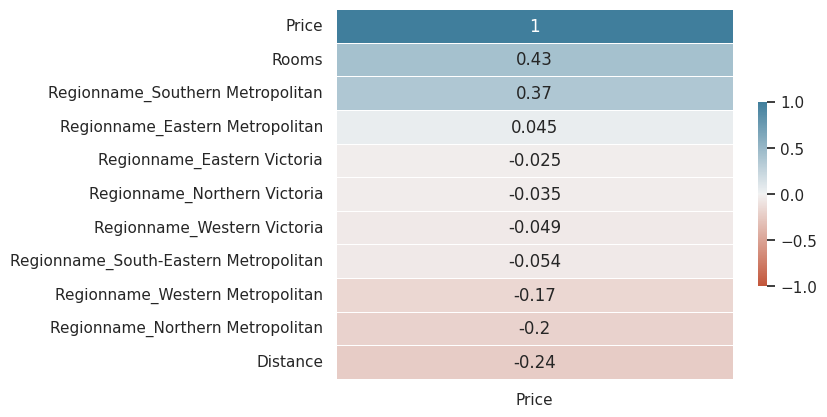

In [ ]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividmos en train test

In [ ]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols

['Regionname_Eastern Metropolitan',
 'Regionname_Eastern Victoria',
 'Regionname_Northern Metropolitan',
 'Regionname_Northern Victoria',
 'Regionname_South-Eastern Metropolitan',
 'Regionname_Southern Metropolitan',
 'Regionname_Western Metropolitan',
 'Regionname_Western Victoria',
 'Rooms',
 'Distance']

In [ ]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

## 2 - ESCALAMIENTO DE DATOS

In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [ ]:
results = {}
for name,model in models.items():
  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [ ]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.479150,0.536284,0.484313
Lasso,0.404575,0.613069,0.521991
Ridge,0.479150,0.536284,0.484309
KNN Regressor,0.632222,0.378676,0.379785
SVR,0.573519,0.439118,0.396970
Random Forest Regressor,0.657399,0.352753,0.363093


# BUSCAMOS EL MEJOR MODELO

In [ ]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.6574)
Best model based on MSE: Random Forest Regressor (MSE: 0.35)


# GRAFICAMOS RESULTADOS

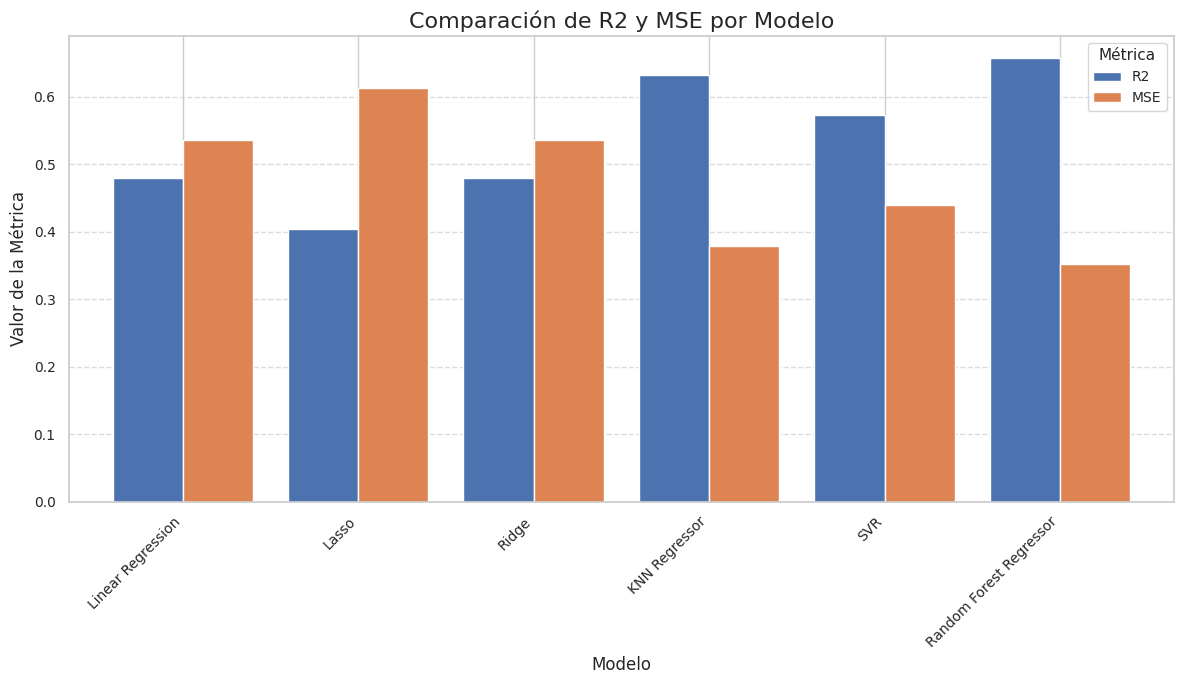

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(models[best_r2_model],'model.pkl')
joblib.dump(scaler_X,'scaler_X.pkl')
joblib.dump(scaler_y,'scaler_y.pkl')

['scaler_y.pkl']

In [ ]:
import joblib
import numpy as np

# Load the best model and scalers
model = joblib.load('model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

def predict_price(new_data):
  # Ensure new_data is a 2D array for scaling
  new_data_array = np.array(new_data).reshape(1, -1)

  # Scale the input data
  new_data_scaled = scaler_X.transform(new_data_array)

  # Make prediction using the model
  prediction_scaled = model.predict(new_data_scaled)

  # Inverse transform the prediction to get original price scale
  prediction = scaler_y.inverse_transform(prediction_scaled.reshape(1, -1))

  return prediction[0][0]

print("Model and scalers loaded. You can now use the 'predict_price' function.")


Model and scalers loaded. You can now use the 'predict_price' function.


In [ ]:
region_name = {
    'Northern Metropolitan': [1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    'Western Metropolitan': [0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0],
    'Southern Metropolitan': [0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0],
    'South-Eastern Metropolitan': [0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0],
    'Eastern Metropolitan': [0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0],
    'Northern Victoria': [0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0],
    'Eastern Victoria': [0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0],
    'Western Victoria': [0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0]
}

In [ ]:
region = 'Western Metropolitan'
rooms = 3
distance = 5
data_list = region_name[region] + [rooms,distance]
data_list

[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3, 5]

In [ ]:
new_house_data = np.array(data_list)

predicted_price = predict_price(new_house_data) * 1000000
print(f"Predicted Price: {predicted_price:.3f} EUROS")

Predicted Price: 989252.074 EUROS
